In [1]:
from sbcasdiego.Datasets.DefaultDataset import DefaultDataset
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../datasets/dropout.csv", sep=";")
df['Target'] = df['Target'].map({'Graduate': 1, 'Dropout': 0, 'Enrolled': 1})
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [3]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [4]:
h = DefaultDataset(
    dataset= df,
    predicted_attr="Target",
    protected_attr=['Gender'],
    protected_attr_mappings={"sex": {"Female": [0], "Male": [1]}},
    positive_outcome=1
)
# h.num_repetitions = 1
# h.execute_models()

Max correlation: Curricular units 2nd sem (grade) (0.5717922029440721)


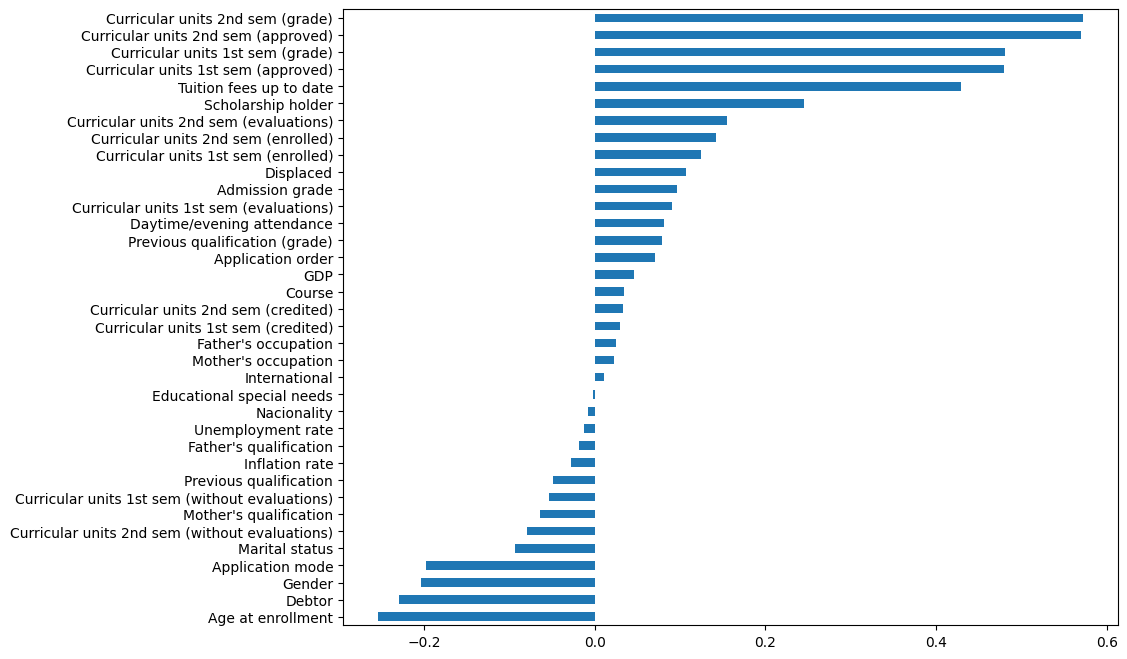

In [5]:
correlations = df.corr()[h.predicted_attr].drop(h.predicted_attr).dropna().sort_values()
correlations.plot(kind='barh', figsize=(10, 8))

max_corr = correlations.abs().idxmax()
print(f"Max correlation: {max_corr} ({correlations[max_corr]})")

In [6]:
h.get_metrics(correlated_vars=max_corr,
    df_train=df)

{'Class Imbalance': {'Gender': -0.2965641952983725},
 'KS': {'Gender': 0.1994681137128782},
 'KL Divergence': {'Gender': 0.09326682832469024},
 'CDDL': {'Gender': -0.2454635663425534}}

In [7]:
protected_attr_mappings = {}
for column in df.columns:
    if df[column].nunique() == 2 and column != h.predicted_attr:
        protected_attr_mappings[column] = {"Privileged": df[column].value_counts().idxmax(), "Unprivileged": df[column].value_counts().idxmin()}
protected_attr_mappings

{'Daytime/evening attendance': {'Privileged': 1, 'Unprivileged': 0},
 'Displaced': {'Privileged': 1, 'Unprivileged': 0},
 'Educational special needs': {'Privileged': 0, 'Unprivileged': 1},
 'Debtor': {'Privileged': 0, 'Unprivileged': 1},
 'Tuition fees up to date': {'Privileged': 1, 'Unprivileged': 0},
 'Gender': {'Privileged': 0, 'Unprivileged': 1},
 'Scholarship holder': {'Privileged': 0, 'Unprivileged': 1},
 'International': {'Privileged': 0, 'Unprivileged': 1}}

In [8]:
h.protected_attr_mappings = protected_attr_mappings
h.protected_attr = list(protected_attr_mappings.keys())
metrics = h.get_metrics(correlated_vars='Curricular units 2nd sem (approved)',
    df_train=df)

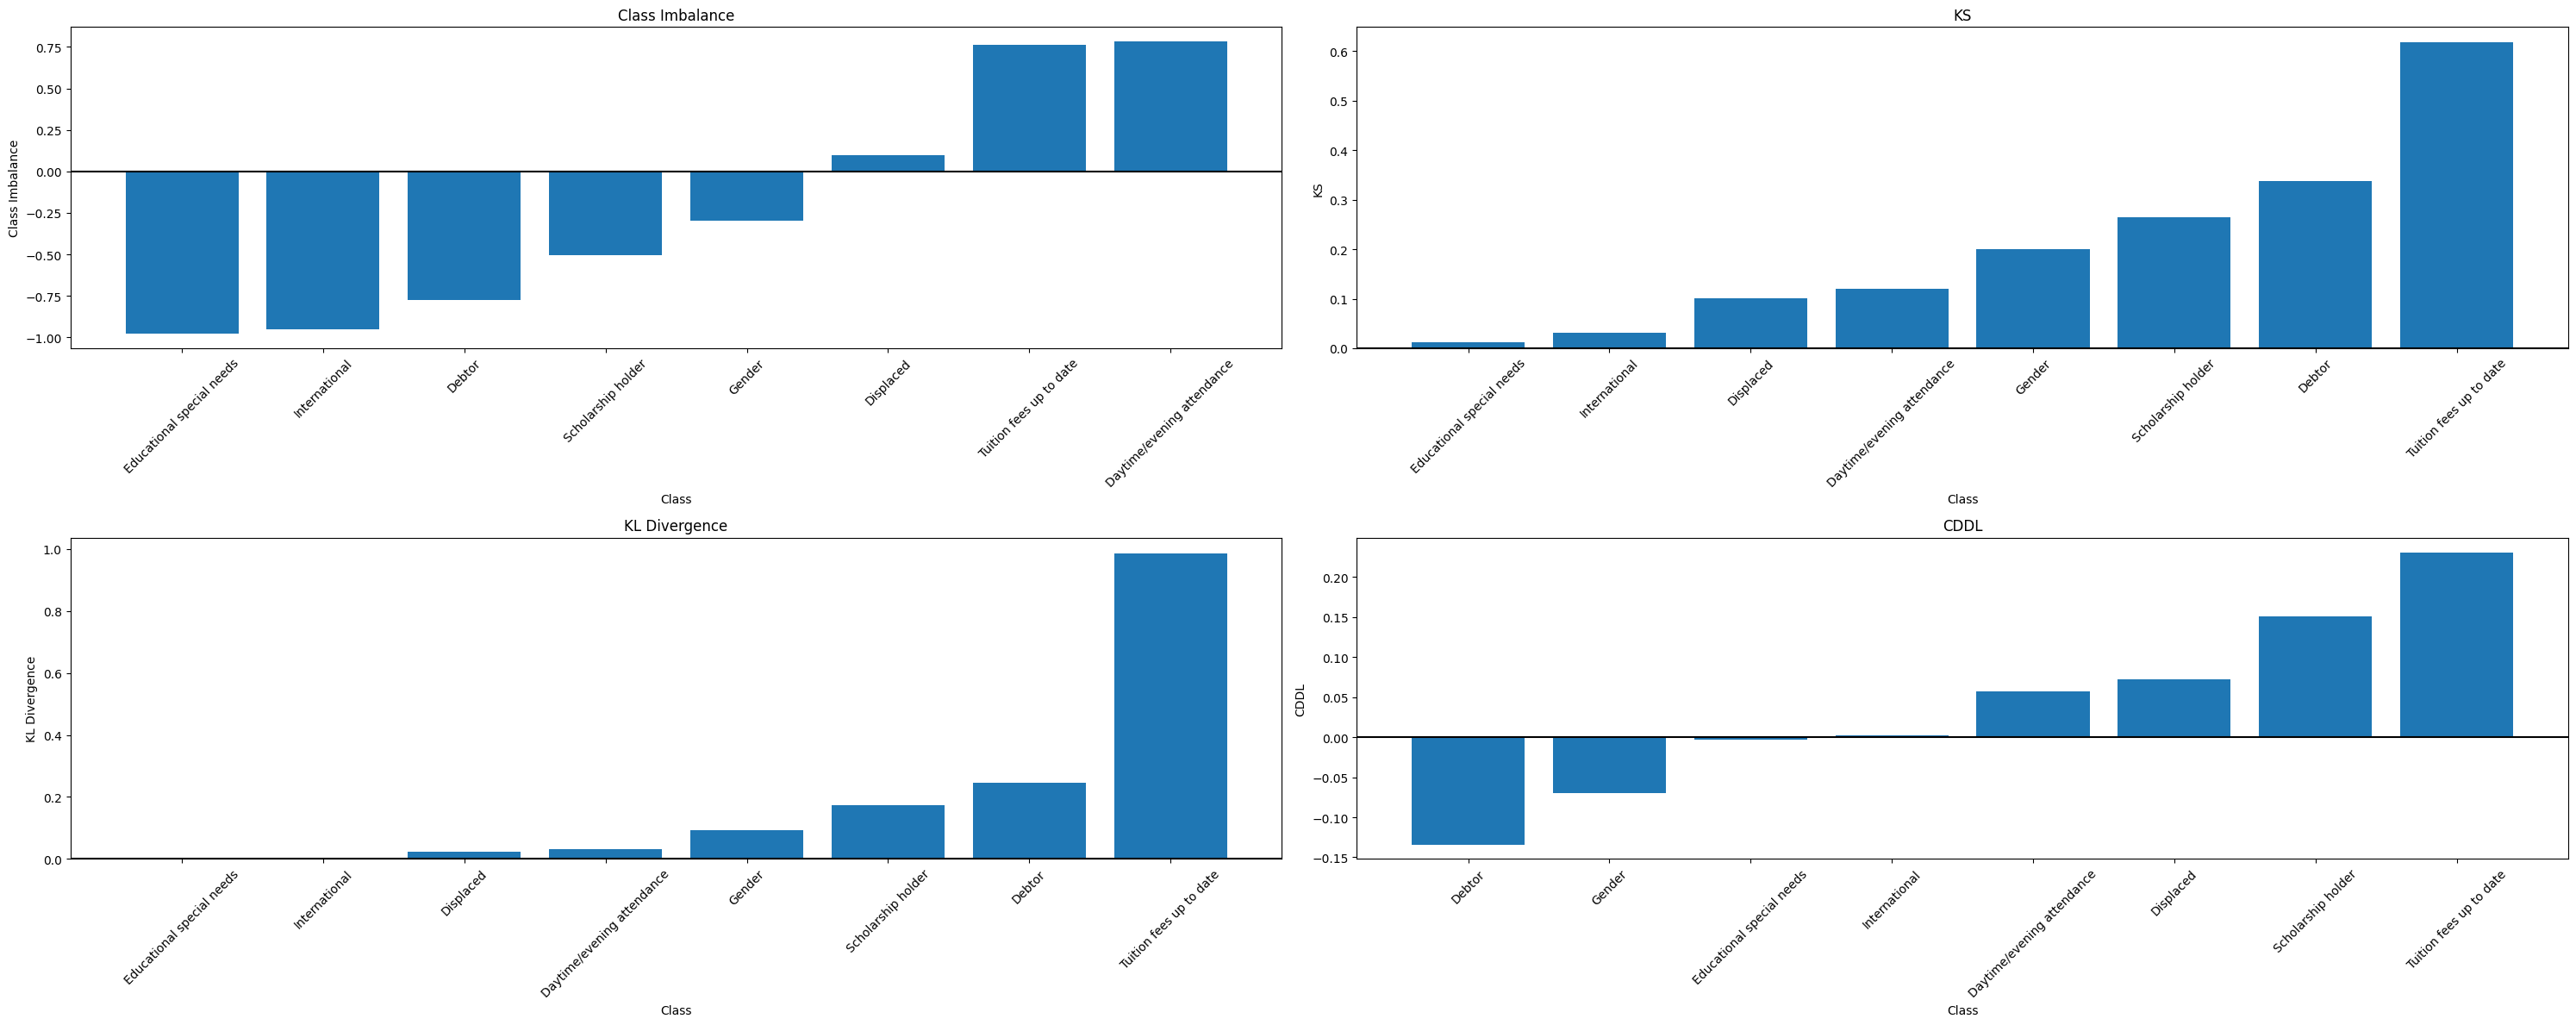

In [10]:
h.get_metrics_graph(metrics, plt, True)